Connecting to Icechunk repository at s3://airborne-smce-prod-user-bucket/JOIN/icechunk-stores/CEDA_Store_v3/...
Opening virtual dataset from Icechunk...
Selecting SWE data for 2019-01-30...
Generating plot (this will fetch the byte-ranges from CEDA via HTTPS)...
Plot saved to swe_global_20190130.png


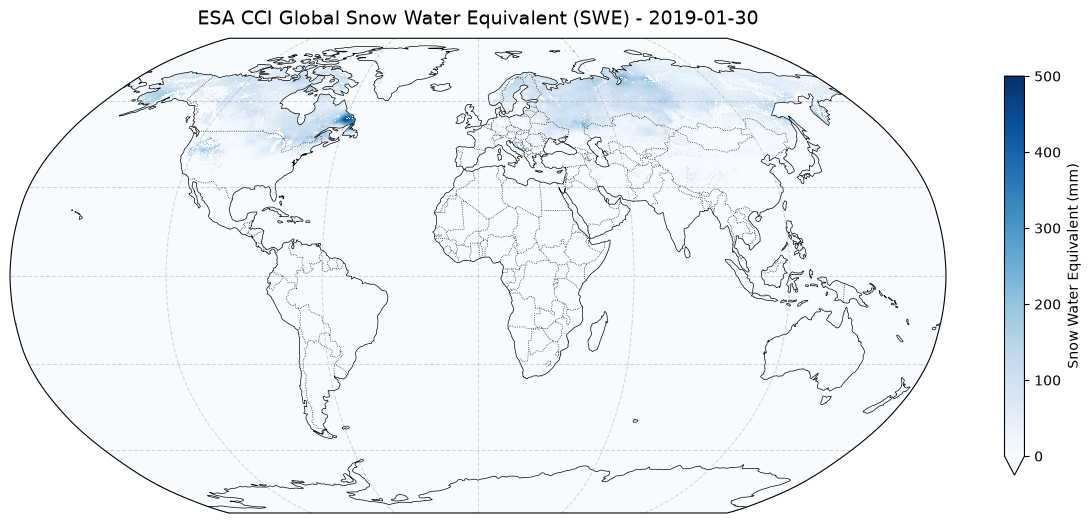

In [2]:
import icechunk
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ==========================================
# 1. Configuration
# ==========================================
bucket = "airborne-smce-prod-user-bucket"
prefix = "JOIN/icechunk-stores/CEDA_Store_v3/"
base_ceda_url = "https://dap.ceda.ac.uk/neodc/esacci/snow/data/swe/MERGED/v4.0/"

print(f"Connecting to Icechunk repository at s3://{bucket}/{prefix}...")

# ==========================================
# 2. Configure Icechunk Access (Read-Only)
# ==========================================
storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)

# We must register the container again so Icechunk knows how to read the pointers
config = icechunk.RepositoryConfig.default()
container = icechunk.VirtualChunkContainer(
    name="ceda_archive",       
    url_prefix=base_ceda_url,  
    store=icechunk.http_store()
)
config.set_virtual_chunk_container(container)

# Open the repository (Notice we use .open instead of .open_or_create for safety)
repo = icechunk.Repository.open(
    storage=storage,
    config=config,
    authorize_virtual_chunk_access={base_ceda_url: icechunk.credentials.HttpAccess}
)

# Open a read-only session on the main branch
session = repo.readonly_session("main")

# ==========================================
# 3. Read and Select the Data
# ==========================================
print("Opening virtual dataset from Icechunk...")
# Open the dataset lazily using the Zarr V3 engine mapping
ds = xr.open_zarr(session.store, zarr_format=3)

print("Selecting SWE data for 2019-01-30...")
# Select the specific date and the 'swe' variable
# .squeeze() removes the time dimension so we are left with a 2D (lat, lon) array
swe_day = ds['swe'].sel(time='2019-01-30').squeeze()

# ==========================================
# 4. Plot on a Global Map
# ==========================================
print("Generating plot (this will fetch the byte-ranges from CEDA via HTTPS)...")

# Set up a Matplotlib figure with a Robinson projection
fig, ax = plt.subplots(
    figsize=(12, 6), 
    subplot_kw={'projection': ccrs.Robinson()}
)

# Add map features for context
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax.gridlines(draw_labels=False, alpha=0.3, color='gray', linestyle='--')

# Plot the SWE data
# Transform=ccrs.PlateCarree() maps the standard Lat/Lon data grid onto the Robinson projection
swe_plot = swe_day.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='Blues',           # Blue color map is standard for snow/water
    vmin=0,                 # Force minimum to 0 to prevent background noise
    cbar_kwargs={
        'label': 'Snow Water Equivalent (mm)', 
        'shrink': 0.7, 
        'orientation': 'vertical'
    }
)

ax.set_title("ESA CCI Global Snow Water Equivalent (SWE) - 2019-01-30", fontsize=14, pad=10)
ax.set_global()  # Zoom out to show the whole world

plt.tight_layout()

# Save the figure locally and show it
output_filename = "swe_global_20190130.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {output_filename}")

plt.show()